# EDA: Dataset Roboflow `Malocclusion-Data` (COCO)

Notebook ini untuk eksplorasi dataset kedua — project Roboflow `benediktas-workspace/malocclusion-data-jln3h`, format **COCO**, sekarang tersimpan lokal di `Dataset/Malocclusion-Data-1/`. Dataset ini **berbeda** dari `omni_coco` (lihat `01_omni_coco_eda.ipynb`) baik dari sisi struktur maupun isi:

- Struktur foldernya **flat per split**: hanya ada `train/` dan `valid/` (tidak ada `test/`), tidak dikelompokkan per pasien/visit seperti `omni_coco`
- Tiap split punya satu file `_annotations.coco.json` di dalam folder split itu sendiri
- Roboflow menyisipkan **1 kategori placeholder ekstra** (`supercategory: "none"`, dalam dataset ini namanya `teeth`) yang merepresentasikan root/dataset itu sendiri — bukan kelas asli, perlu difilter
- Ada **30 kelas asli** dengan pola kode `1`, `2a`–`2g`, `3a`–`3f`, `4a`–`4f`/`4h`/`4l`/`4m`/`4t`, `5a`/`5h`/`5i`/`5m`/`5p`/`5s` — arti kode ini belum diketahui (perlu dicek ke sumber dataset/README Roboflow), jadi glossary belum bisa ditambahkan seperti di `omni_coco`
- **Gambar resolusi asli, ukurannya TIDAK seragam** (ratusan kombinasi width/height berbeda) — beda jauh dari `omni_coco` yang seragam 512×341. Ini penting untuk strategi resize sebelum training
- Nama file gambar diubah Roboflow jadi pola `<nama_asli>_jpg.rf.<hash>.jpg`, tapi nama file asli masih tersimpan di field `images[i].extra.name`

Tujuan notebook sama seperti EDA pertama: pahami ukuran dataset, distribusi kelas, statistik bbox, cek integritas, dan visualisasi sampel.

## 1. Setup

Pakai dataset lokal yang sudah ada di `Dataset/Malocclusion-Data-1/` kalau tersedia. Kalau belum ada (mis. dijalankan di environment lain), baru download dari Roboflow — API key diminta interaktif lewat `getpass`, tidak ditulis langsung di notebook.

In [3]:
import json
from getpass import getpass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [4]:
LOCAL_DATASET_DIR = Path("../Dataset/Malocclusion-Data-1")

if LOCAL_DATASET_DIR.exists():
    ROOT = LOCAL_DATASET_DIR
    print(f"Pakai dataset lokal: {ROOT.resolve()}")
else:
    print("Dataset lokal belum ditemukan, download dari Roboflow...")
    %pip install -q roboflow
    from roboflow import Roboflow

    api_key = getpass("Roboflow API key: ")
    rf = Roboflow(api_key=api_key)
    project = rf.workspace("benediktas-workspace").project("malocclusion-data-jln3h")
    version = project.version(1)
    dataset = version.download("coco", location=str(LOCAL_DATASET_DIR))
    ROOT = Path(dataset.location)
    print(f"Dataset terdownload di: {ROOT.resolve()}")

SPLITS = [d.name for d in ROOT.iterdir() if d.is_dir() and (d / "_annotations.coco.json").exists()]
print("Split yang ditemukan:", SPLITS)


Pakai dataset lokal: /Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/Malocclusion-Data-1
Split yang ditemukan: ['valid', 'train']


## 2. Load anotasi COCO per split

File anotasi ada di dalam masing-masing folder split (`<split>/_annotations.coco.json`), sejajar dengan gambar-gambarnya.

In [5]:
raw = {}
for split in SPLITS:
    with open(ROOT / split / "_annotations.coco.json") as f:
        raw[split] = json.load(f)

categories_raw = pd.DataFrame(raw[SPLITS[0]]["categories"])[["id", "name", "supercategory"]]
categories_raw


,id,name,supercategory
0,0,teeth,none
1,1,1,teeth
2,2,2a,teeth
3,3,2b,teeth
4,4,2c,teeth
5,5,2d,teeth
6,6,2e,teeth
7,7,2f,teeth
8,8,2g,teeth
9,9,3a,teeth


### 2.1 Filter kategori placeholder Roboflow

Kategori dengan `supercategory == "none"` adalah placeholder root yang otomatis dibuat Roboflow — bukan kelas anotasi asli. Kita keluarkan dari daftar kelas yang dipakai untuk analisis.

In [6]:
categories = categories_raw[categories_raw["supercategory"] != "none"].reset_index(drop=True)
cat_id_to_name = dict(zip(categories["id"], categories["name"]))

placeholder = categories_raw[categories_raw["supercategory"] == "none"]
print(f"Kategori placeholder yang difilter: {placeholder['name'].tolist()}")
print(f"Kategori asli (dipakai anotasi): {len(categories)}")
categories


Kategori placeholder yang difilter: ['teeth']
Kategori asli (dipakai anotasi): 30


,id,name,supercategory
0,1,1,teeth
1,2,2a,teeth
2,3,2b,teeth
3,4,2c,teeth
4,5,2d,teeth
5,6,2e,teeth
6,7,2f,teeth
7,8,2g,teeth
8,9,3a,teeth
9,10,3b,teeth


**Catatan:** arti tiap kode kelas (`1`, `2a`, `3c`, dst.) belum diketahui dari file COCO-nya sendiri (`info`/`licenses` tidak berisi glossary). Perlu dicek ke README Roboflow / sumber dataset asli sebelum dipakai untuk interpretasi klinis — sama seperti proses yang dilakukan untuk `omni_coco` sebelumnya.

In [7]:
images = {}
annotations = {}

for split in SPLITS:
    imgs = pd.DataFrame(raw[split]["images"])
    imgs["split"] = split
    images[split] = imgs

    anns = pd.DataFrame(raw[split]["annotations"])
    anns["split"] = split
    anns["category_name"] = anns["category_id"].map(cat_id_to_name)
    annotations[split] = anns

images_all = pd.concat(images.values(), ignore_index=True)
annotations_all = pd.concat(annotations.values(), ignore_index=True)

images_all.head()


,id,license,file_name,height,width,date_captured,extra,split
0,0,1,IMG_9996_JPG.rf.46e2185d4dd5f002e3de29be7cf9e6...,3456,5184,2026-07-20T03:58:46+00:00,"{'user_tags': ['1'], 'name': 'IMG_9996.JPG'}",valid
1,1,1,IMG_0008_JPG.rf.594857464050ef6083d2f9b41403fe...,3456,5184,2026-07-20T03:58:46+00:00,"{'user_tags': ['Canon', '11'], 'name': 'IMG_00...",valid
2,2,1,IMG_9945_JPG.rf.c0589c97af8ed07b3af5857dae4aed...,3456,5184,2026-07-20T03:58:46+00:00,"{'user_tags': ['Canon', '11'], 'name': 'IMG_99...",valid
3,3,1,IMG_9955_JPG.rf.08d01fa1997d9f45cfb40575fd0543...,3456,5184,2026-07-20T03:58:46+00:00,"{'user_tags': ['Canon', '11'], 'name': 'IMG_99...",valid
4,4,1,IMG_0005_JPG.rf.8177f74b9ac547dc731e42fa513b28...,3456,5184,2026-07-20T03:58:46+00:00,"{'user_tags': ['Canon', '11'], 'name': 'IMG_00...",valid


In [8]:
annotations_all.head()


,id,image_id,category_id,bbox,iscrowd,area,segmentation,split,category_name
0,1,0,18,"[2160.38, 632.46, 1039.05, 1181.11]",0,1227232.345,[],valid,4d
1,2,0,14,"[3460, 515, 1555, 1710]",0,2659050.000,[],valid,3f
2,3,1,18,"[979.43, 2000.49, 630, 975]",0,614250.000,[],valid,4d
3,4,1,4,"[2512.68, 1470.8, 762.42, 1581.71]",0,1205927.338,[],valid,2c
4,5,1,1,"[3653.38, 1344.26, 1530.62, 1176.57]",0,1800881.573,[],valid,1


## 3. Ringkasan dataset per split

In [9]:
summary_rows = []
for split in SPLITS:
    imgs = images[split]
    anns = annotations[split]
    summary_rows.append({
        "split": split,
        "n_images": len(imgs),
        "n_annotations": len(anns),
        "avg_anns_per_image": len(anns) / len(imgs) if len(imgs) else float("nan"),
    })

summary = pd.DataFrame(summary_rows).set_index("split")
summary


,n_images,n_annotations,avg_anns_per_image
split,,,
valid,50,131,2.620000
train,576,1286,2.232639


In [10]:
print(f"Total gambar : {len(images_all)}")
print(f"Total anotasi: {len(annotations_all)}")


Total gambar : 626
Total anotasi: 1417


## 4. Cek integritas data

### 4.1 Ukuran gambar

Beda dari `omni_coco` yang seragam 512×341, dataset ini berisi foto resolusi asli (belum di-resize Roboflow) sehingga ukurannya bervariasi antar gambar. Kita lihat sebarannya, bukan cek keseragaman.

In [11]:
print("Jumlah kombinasi (width, height) unik:", images_all[["width", "height"]].drop_duplicates().shape[0], "dari", len(images_all), "gambar")
images_all[["width", "height"]].describe()


Jumlah kombinasi (width, height) unik: 188 dari 626 gambar


,width,height
count,626.000000,626.000000
mean,5372.017572,3622.956869
std,623.919419,498.859541
min,3456.000000,2435.000000
25%,5184.000000,3456.000000
50%,5184.000000,3456.000000
75%,6000.000000,4000.000000
max,6240.000000,6000.000000


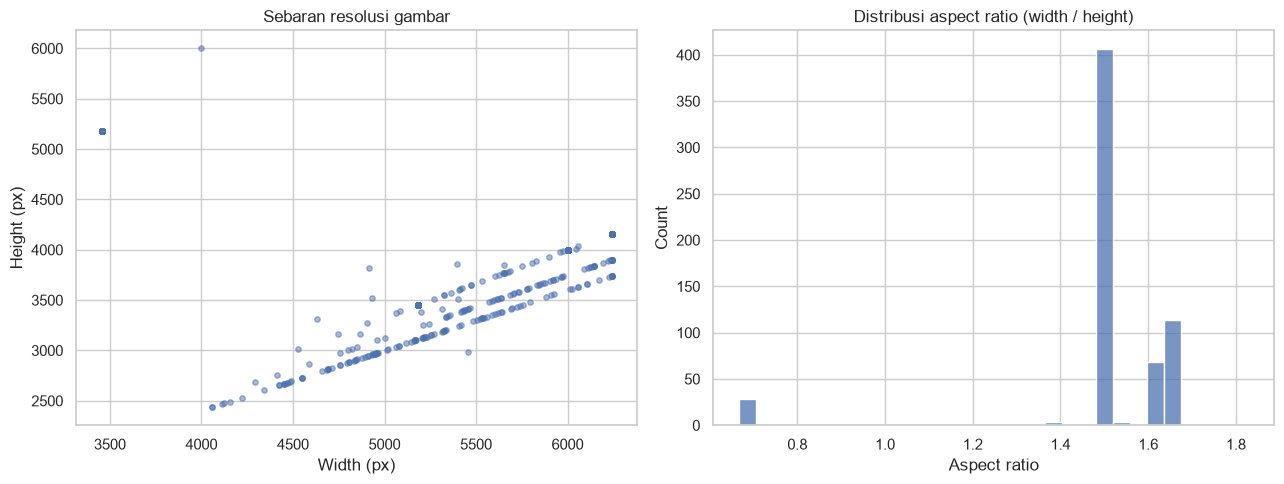

In [12]:
images_all["aspect_ratio"] = images_all["width"] / images_all["height"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(images_all["width"], images_all["height"], alpha=0.5, s=15)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Sebaran resolusi gambar")

sns.histplot(images_all["aspect_ratio"], bins=30, ax=axes[1])
axes[1].set_title("Distribusi aspect ratio (width / height)")
axes[1].set_xlabel("Aspect ratio")

plt.tight_layout()
plt.show()


### 4.2 File hilang & anotasi/gambar yatim

In [13]:
missing_files = []
for split in SPLITS:
    imgs = images[split]
    for _, row in imgs.iterrows():
        path = ROOT / split / row["file_name"]
        if not path.exists():
            missing_files.append(str(path))

print(f"File hilang dari {len(images_all)} gambar yang dicek: {len(missing_files)}")
if missing_files:
    print(missing_files[:10])


File hilang dari 626 gambar yang dicek: 0


In [14]:
for split in SPLITS:
    img_ids = set(images[split]["id"])
    ann_img_ids = set(annotations[split]["image_id"])
    orphan_anns = ann_img_ids - img_ids
    images_without_ann = img_ids - ann_img_ids
    print(f"[{split}] anotasi tanpa image terkait: {len(orphan_anns)} | gambar tanpa anotasi: {len(images_without_ann)}")


[valid] anotasi tanpa image terkait: 0 | gambar tanpa anotasi: 0
[train] anotasi tanpa image terkait: 0 | gambar tanpa anotasi: 2


## 5. Distribusi kategori

Dengan 30 kelas, dipakai horizontal bar chart supaya label kelas tetap terbaca.

In [15]:
cat_counts = (
    annotations_all
    .groupby(["split", "category_name"])
    .size()
    .unstack("split")
    .reindex(categories["name"])
    .fillna(0)
    .astype(int)
)
cat_counts["total"] = cat_counts[SPLITS].sum(axis=1)
cat_counts.sort_values("total", ascending=False)


split,train,valid,total
name,,,
3d,169,14,183
4d,151,30,181
1,161,15,176
2d,138,7,145
2g,90,10,100
5i,76,6,82
4h,75,2,77
3c,51,8,59
3f,43,10,53


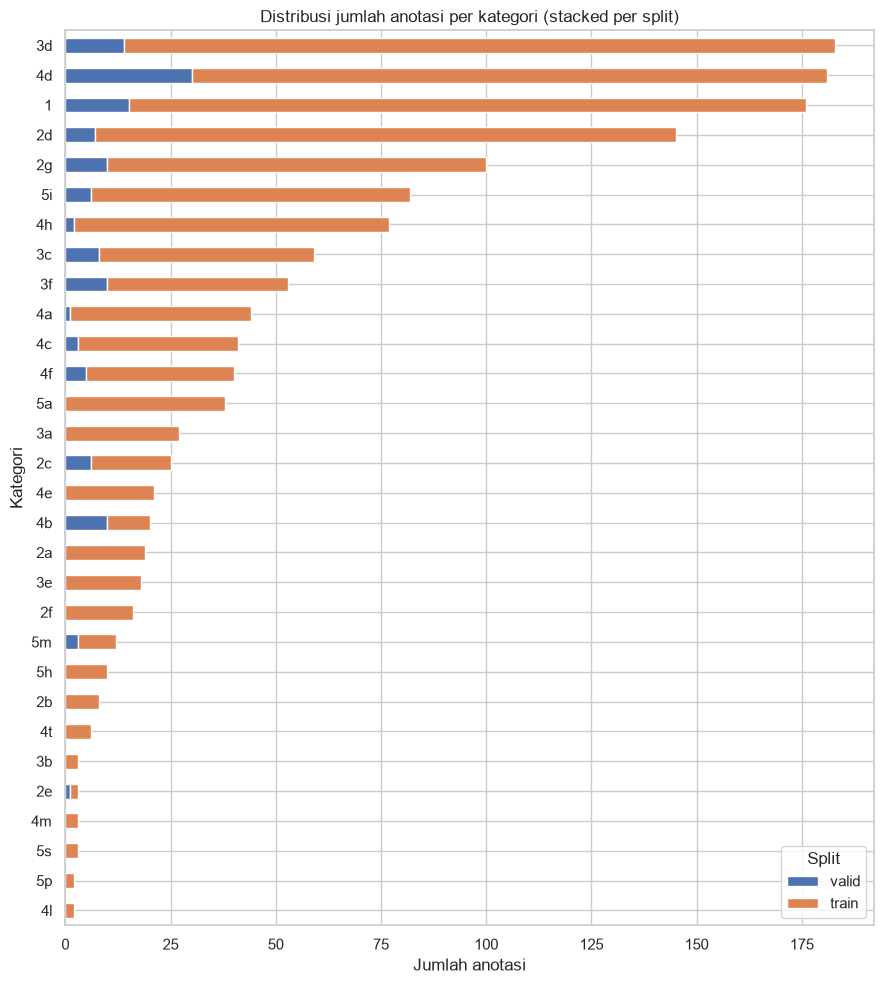

In [16]:
order = cat_counts.sort_values("total", ascending=True).index

fig, ax = plt.subplots(figsize=(9, 10))
cat_counts.loc[order, SPLITS].plot(kind="barh", stacked=True, ax=ax)
ax.set_title("Distribusi jumlah anotasi per kategori (stacked per split)")
ax.set_ylabel("Kategori")
ax.set_xlabel("Jumlah anotasi")
ax.legend(title="Split")
plt.tight_layout()
plt.show()


In [17]:
n_classes_with_data = (cat_counts["total"] > 0).sum()
n_classes_zero = (cat_counts["total"] == 0).sum()
print(f"Kelas dengan minimal 1 anotasi: {n_classes_with_data} dari {len(cat_counts)}")
if n_classes_zero:
    print("Kelas tanpa anotasi sama sekali:", cat_counts[cat_counts['total'] == 0].index.tolist())


Kelas dengan minimal 1 anotasi: 30 dari 30


## 6. Jumlah anotasi per gambar

Dataset ini jauh lebih jarang anotasinya per gambar dibanding `omni_coco` (di sana rata-rata ~14-15 per foto).

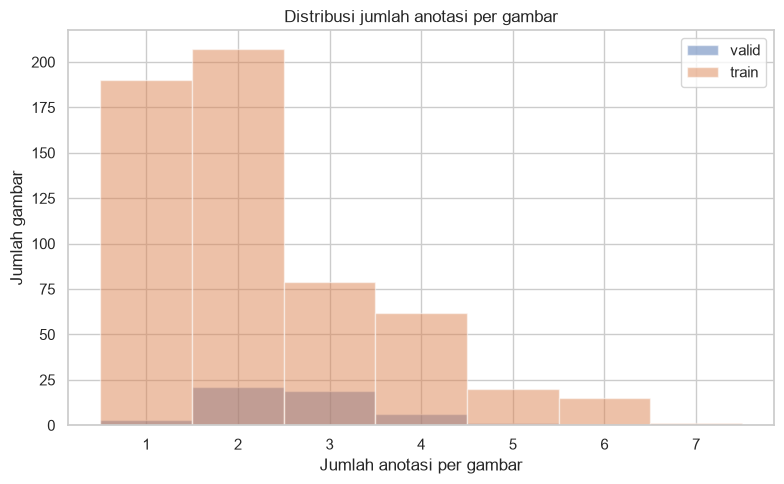

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
train,574.0,2.240418,1.273178,1.0,1.0,2.0,3.0,7.0
valid,50.0,2.620000,0.854520,1.0,2.0,3.0,3.0,5.0


In [18]:
anns_per_image = annotations_all.groupby(["split", "image_id"]).size().reset_index(name="n_anns")

fig, ax = plt.subplots(figsize=(8, 5))
for split in SPLITS:
    subset = anns_per_image[anns_per_image["split"] == split]["n_anns"]
    ax.hist(subset, bins=range(1, subset.max() + 2), alpha=0.5, label=split, align="left")
ax.set_title("Distribusi jumlah anotasi per gambar")
ax.set_xlabel("Jumlah anotasi per gambar")
ax.set_ylabel("Jumlah gambar")
plt.legend()
plt.tight_layout()
plt.show()

anns_per_image.groupby("split")["n_anns"].describe()


## 7. Statistik ukuran bounding box

Karena gambar tidak seragam ukurannya, `bbox_w`/`bbox_h` absolut kurang bermakna dibandingkan antar kategori — kita fokus ke ukuran **relatif terhadap gambar masing-masing**.

In [19]:
bbox = annotations_all["bbox"].apply(pd.Series)
bbox.columns = ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]
ann_bbox = pd.concat([annotations_all.reset_index(drop=True), bbox], axis=1)

img_dims = images_all.set_index("id")[["width", "height"]]
ann_bbox = ann_bbox.join(img_dims, on="image_id")
ann_bbox["bbox_w_rel"] = ann_bbox["bbox_w"] / ann_bbox["width"]
ann_bbox["bbox_h_rel"] = ann_bbox["bbox_h"] / ann_bbox["height"]
ann_bbox["area_rel"] = ann_bbox["bbox_w_rel"] * ann_bbox["bbox_h_rel"]

ann_bbox.groupby("category_name")[["bbox_w_rel", "bbox_h_rel", "area_rel"]].agg(["count", "mean", "median"])


bbox_w_rel                     bbox_h_rel                      \
                   count      mean    median      count      mean    median   
category_name                                                                 
1                    214  0.280074  0.262878        214  0.544631  0.585994   
2a                    19  0.155416  0.158598         19  0.402777  0.422212   
2b                     9  0.172594  0.147231          9  0.468105  0.480894   
2c                    32  0.142146  0.135703         32  0.418933  0.403942   
2d                   163  0.166800  0.166386        163  0.265690  0.249923   
2e                     4  0.311351  0.339713          4  0.489748  0.472297   
2f                    16  0.262356  0.246142         16  0.396948  0.409447   
2g                   117  0.373210  0.369376        117  0.437712  0.432395   
3a                    27  0.226774  0.183162         27  0.401173  0.423747   
3b                     3  0.299783  0.229994          3  0.491035  0.494987   
3c                    75  0.198124  0.177328         75  0.392742  0.384314   
3d                   214  0.172943  0.171550        214  0.276924  0.260492   
3e                    19  0.282892  0.270865         19  0.432436  0.444155   
3f                    66  0.282280  0.277159         66  0.374839  0.371467   
4a                    48  0.221539  0.200653         48  0.414938  0.404747   
4b                    30  0.305218  0.295391         30  0.394114  0.364298   
4c                    48  0.200192  0.168286         48  0.415560  0.419197   
4d                   225  0.186234  0.177132        225  0.313020  0.307251   
4e                    23  0.404620  0.423349         23  0.427878  0.446568   
4f                    46  0.294004  0.294310         46  0.402979  0.441325   
4h                    87  0.249047  0.237017         87  0.351950  0.345775   
4l                     2  0.163484  0.163484          2  0.285735  0.285735   
4m                     3  0.302088  0.233750          3  0.526775  0.534145   
4t                     6  0.232954  0.214556          6  0.321032  0.272031   
5a                    43  0.275024  0.244297         43  0.443007  0.432550   
5h                    10  0.299332  0.300898         10  0.393658  0.365224   
5i                    95  0.248377  0.239018         95  0.338840  0.323607   
5m                    15  0.260840  0.243389         15  0.417929  0.408892   
5p                     2  0.525552  0.525552          2  0.510429  0.510429   
5s                     3  0.195584  0.190340          3  0.244406  0.247396   

              area_rel                      
                 count      mean    median  
category_name                               
1                  214  0.153400  0.156029  
2a                  19  0.066087  0.071398  
2b                   9  0.084347  0.070498  
2c                  32  0.061107  0.058187  
2d                 163  0.045292  0.040380  
2e                   4  0.154571  0.158901  
2f                  16  0.106058  0.088868  
2g                 117  0.165977  0.161067  
3a                  27  0.091551  0.078807  
3b                   3  0.147475  0.111044  
3c                  75  0.078677  0.067691  
3d                 214  0.049915  0.046471  
3e                  19  0.127215  0.147366  
3f                  66  0.107705  0.102103  
4a                  48  0.090933  0.086056  
4b                  30  0.119731  0.114451  
4c                  48  0.083669  0.076376  
4d                 225  0.060281  0.053787  
4e                  23  0.172860  0.195435  
4f                  46  0.121150  0.111975  
4h                  87  0.087768  0.087269  
4l                   2  0.047231  0.047231  
4m                   3  0.156872  0.127377  
4t                   6  0.078430  0.058326  
5a                  43  0.119729  0.112453  
5h                  10  0.114030  0.121051  
5i                  95  0.084696  0.085101  
5m                  15  0.113145  0.101010  
5p         

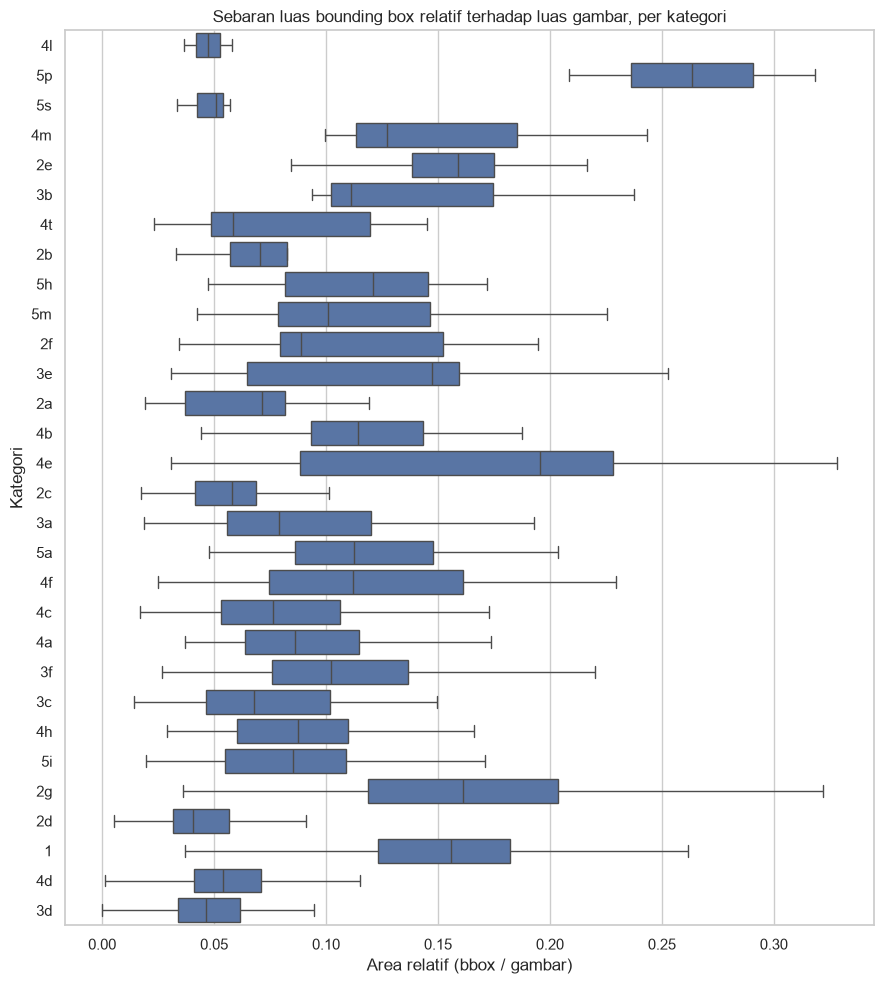

In [20]:
fig, ax = plt.subplots(figsize=(9, 10))
sns.boxplot(data=ann_bbox, y="category_name", x="area_rel", order=order, ax=ax, showfliers=False)
ax.set_title("Sebaran luas bounding box relatif terhadap luas gambar, per kategori")
ax.set_ylabel("Kategori")
ax.set_xlabel("Area relatif (bbox / gambar)")
plt.tight_layout()
plt.show()


## 8. Visualisasi sampel gambar dengan bounding box

Gambar aslinya beresolusi tinggi (bisa >5000px), jadi di-*thumbnail* dulu untuk tampilan — koordinat bbox ikut discale supaya tetap pas.

In [21]:
def plot_image_with_boxes(split, image_id, ax, max_dim=1000):
    img_row = images[split].set_index("id").loc[image_id]
    img_path = ROOT / split / img_row["file_name"]
    img = Image.open(img_path)
    orig_w = img.width
    img_disp = img.copy()
    img_disp.thumbnail((max_dim, max_dim))
    scale = img_disp.width / orig_w
    ax.imshow(img_disp)

    boxes = annotations[split][annotations[split]["image_id"] == image_id]
    for _, box in boxes.iterrows():
        x, y, w, h = [v * scale for v in box["bbox"]]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 3, 0), box["category_name"], color="white", fontsize=8,
                 bbox=dict(facecolor="red", alpha=0.6, pad=0.5))

    extra = img_row.get("extra")
    title = extra["name"] if isinstance(extra, dict) and "name" in extra else img_row["file_name"]
    ax.set_title(f"{split} | {title}", fontsize=9)
    ax.axis("off")


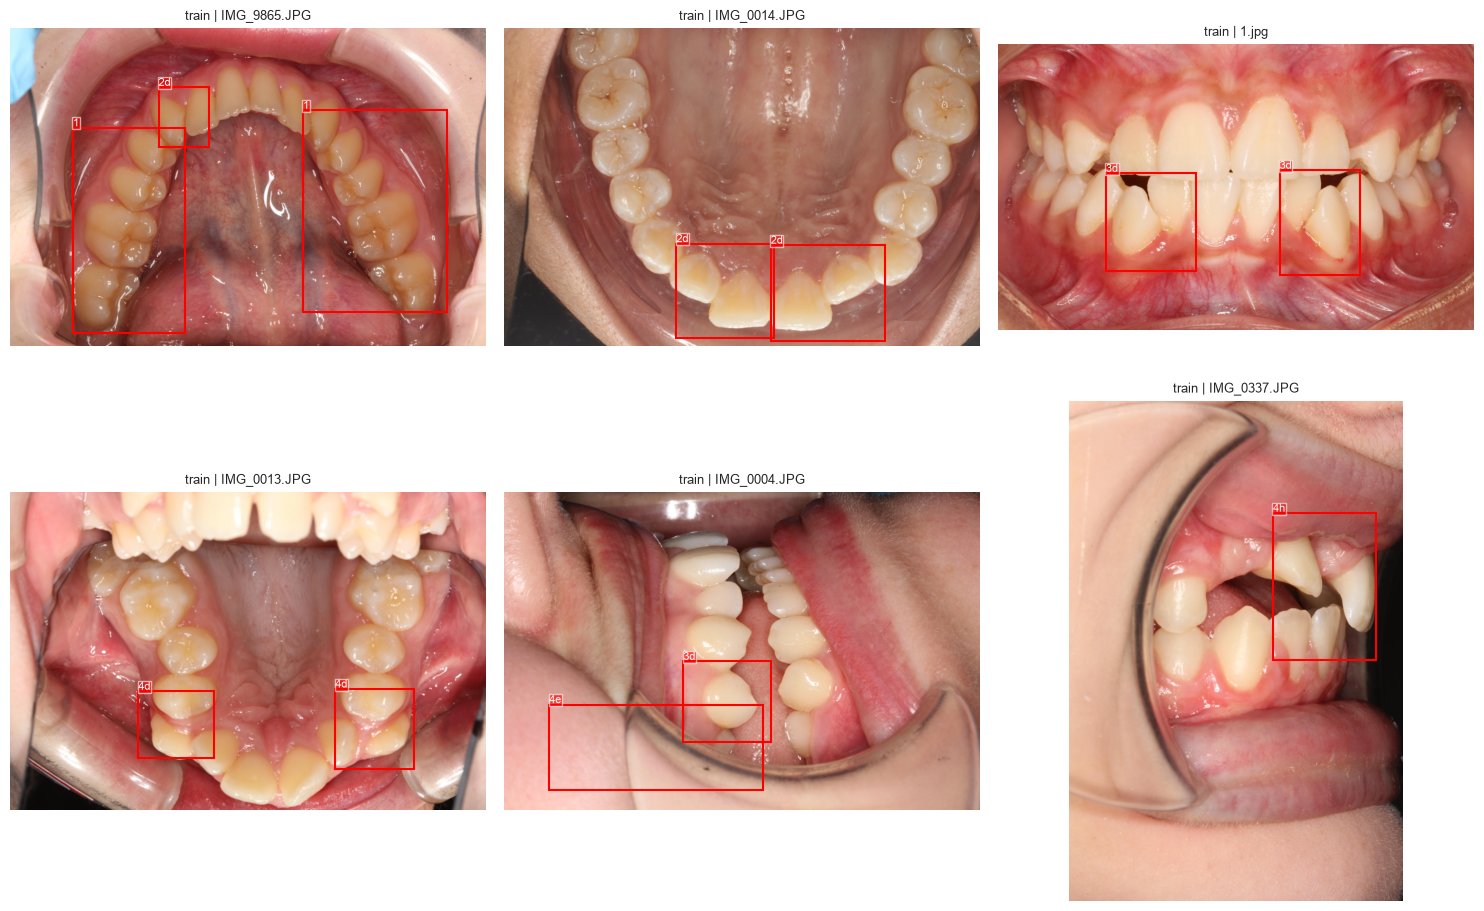

In [22]:
n_samples = min(6, len(images["train"]))
sample_image_ids = images["train"]["id"].sample(n_samples, random_state=1).tolist()

n_cols = 3
n_rows = -(-n_samples // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = np.array(axes).reshape(-1)
for image_id, ax in zip(sample_image_ids, axes):
    plot_image_with_boxes("train", image_id, ax)
for ax in axes[len(sample_image_ids):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 9. Catatan / temuan awal

**Ukuran & integritas data**
- Total 626 gambar, 1417 anotasi — split cuma `train` (576 gambar/1286 anotasi) dan `valid` (50 gambar/131 anotasi), **tidak ada `test`**.
- Tidak ada file hilang, tidak ada anotasi yatim. Ada 2 gambar di train tanpa anotasi sama sekali (perlu dicek manual).
- Dataset ini **jauh lebih kecil** dari `omni_coco`: ~6.7x lebih sedikit gambar (626 vs 4166) dan ~43x lebih sedikit anotasi (1417 vs 61138). Perlu dipikirkan apakah ini cukup untuk training dari awal (from scratch), atau lebih realistis pakai transfer learning/augmentasi berat, atau digabung dengan sumber data lain.

**Class imbalance jauh lebih parah dari `omni_coco`, dan ada masalah di split valid**
- Kelas paling banyak `3d` = 183 instance, paling sedikit `4l` dan `5p` masing-masing cuma 2 instance — rasio ~91:1.
- **14 dari 30 kelas (hampir separuh) sama sekali tidak punya instance di split `valid`**: `5a`, `3a`, `4e`, `2a`, `3e`, `2f`, `5h`, `2b`, `4t`, `3b`, `4m`, `5s`, `4l`, `5p`. Ini masalah serius — kelas-kelas ini tidak bisa dievaluasi sama sekali dengan split yang ada sekarang, meskipun secara teknis "30 dari 30 kelas punya minimal 1 anotasi" kalau dihitung gabungan train+valid.
- Implikasi: split train/valid saat ini kemungkinan perlu di-stratifikasi ulang (atau minimal digabung dulu lalu displit ulang secara stratified) sebelum dipakai untuk training+evaluasi yang bermakna per kelas. Beberapa kelas dengan total instance sangat sedikit (≤3: `4l`, `5p`, `3b`, `4m`, `2e`, `5s`) mungkin perlu digabung dengan kelas terdekat atau dikeluarkan dari task klasifikasi utama.

**Karakteristik bounding box sangat berbeda dari `omni_coco`**
- Di `omni_coco`, bbox kecil (~1-3% luas gambar, per-gigi). Di dataset ini, bbox jauh lebih besar — rata-rata ~5-27% luas gambar tergantung kelas, bahkan kelas `1` rata-rata menutupi ~15% dan `5p` ~26% dari luas gambar.
- Ini mengindikasikan anotasi di sini kemungkinan berupa **region/zona** yang lebih luas (mis. kuadran atau segmen lengkung gigi), bukan temuan per-gigi individual seperti `omni_coco`. Perlu dikonfirmasi ke sumber dataset — ini akan memengaruhi bagaimana crop/patch dibuat kalau nanti dipakai untuk classifier berbasis crop.

**Ukuran gambar sangat bervariasi**
- 188 kombinasi resolusi berbeda dari 626 gambar (rentang 3456×2435 sampai 6240×6000) — ini foto resolusi asli kamera (kemungkinan dari beberapa device berbeda, ada tag `Canon` di field `extra.user_tags`), belum diseragamkan seperti `omni_coco` (512×341 seragam).
- Wajib ada strategi resize/padding yang konsisten sebelum training (Faster R-CNN atau GraphTeethNet), dan bbox harus ikut di-scale sesuai transformasi resize yang dipilih.

**Risiko data leakage — belum diverifikasi (beda dari `omni_coco`)**
- `omni_coco` punya field `subfolder1` (ID pasien) eksplisit sehingga leakage antar split bisa langsung dicek — sudah dipastikan aman di notebook pertama.
- Dataset ini **flat**, tidak ada field ID pasien/sesi eksplisit. Field `extra.user_tags` (contoh: `['Canon', '11']`, `['1']`) kemungkinan menyimpan info device/sesi yang *mungkin* bisa dipakai untuk merekonstruksi pengelompokan pasien/sesi — ini belum digali lebih lanjut. **Sebelum training, perlu dicek dulu apakah foto dari orang/sesi yang sama bisa nyasar ke train dan valid sekaligus**, karena kalau iya itu bisa bikin skor validasi terlalu optimis.

**Yang masih perlu diverifikasi**
- Arti tiap kode kelas (`1`, `2a`, `3c`, dst.) — lihat catatan di section 2, belum ada glossary resmi seperti `omni_coco`.
- Tidak ada split `test` terpisah — kalau butuh holdout akhir untuk evaluasi final, perlu di-carve manual dari data yang ada (dengan tetap menjaga tidak ada leakage) atau diminta tambahan dari sumber Roboflow.
- 2 gambar train tanpa anotasi belum dicek manual.
